# **Esame del 29 agosto 2025**

- Non si possono consultare libri, note, ed ogni altro materiale o persone durante
l’esame ad eccezione delle funzioni Python fornite.

- Risolvere i seguenti esercizi con l’ausilio di Python.

- La durata del compito è di 90 minuti.

- Questo esame ha 3 domande, per un totale di 30/30 punti.

- Svolgere gli esercizi marcati con **[T]** su fogli protocollo, indicando: nome, cognome, codice persona
e data

# **Esercizio 1 (punti 10)**

Sia dato un vettore $x \in \mathbb{R}^N$. Si consideri la matrice $A \in \mathbb{R}^{N\times N}$ il cui elemento generico e' dato da
$$
    a_{ij} = x_i^{N - j-1}
$$
Si consideri $N$ e $x$ dato dal seguente codice.

In [1]:
#prova

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from utilis_sistemi_lineari import *

N = 5
x = np.linspace(0, 1.0, N)

#### **(1a) (3 punti) [P]**  

Scrivere una funzione che, dato in ingresso $x$, restituisce la matrice $A$.

In [6]:
def matrice(x):
    N=len(x)
    A=np.zeros((N,N))
    for i in range(N):
        for j in range(N):
            A[i,j]=x[i]**(N-j-1)
    return(A)

##### **Soluzione.**

Una possibile implementazione e' la seguente

In [ ]:
def matrice(x):
    num = len(x)
    A = np.zeros((num, num))
    for i in range(num):
        for j in range(num):
            A[i, j] = x[i] ** (num - j - 1)
    return A

#### **(1b) (3 punti) [T+P]**

Si enunci il criterio necessario affinche' sia possibile effettuare la fattorizzazione LU (senza pivoting). Verificarlo quindi numericamente per la matrice $A$.

In [20]:
from scipy.linalg import eigvals
A=matrice(x)

marker=True
for i in range(N):
    if np.linalg.det(A[:i+1,:i+1])<1e-8:
        marker=False
    
if marker==False:
    print("il criterio non è verificato")
else:
    print("il criterio è verificato")
    

il criterio non è verificato


##### **Soluzione.**

Definiamo le sotto-matrici principali $A_i$ di $A$ come le matrici ottenute estraendo da
$A$ le sole prime $i$-righe e colonne:
\begin{gather*}
    A_1 = [a_{11}]
    \quad
    A_2 =
    \begin{bmatrix}
        a_{11} & a_{12} \\
        a_{21} & a_{22}
    \end{bmatrix}
    \quad
    A_3 =
    \begin{bmatrix}
        a_{11} & a_{12} & a_{13} \\
        a_{21} & a_{22} & a_{23} \\
        a_{31} & a_{32} & a_{33}
    \end{bmatrix}
    \quad
    \ldots
\end{gather*}

Data una matrice $A\in \mathbb{R}^{N\times N}$ non singolare, la sua
fattorizzazione $LU$ esiste ed \`e unica se e solo se le sotto-matrici
principali $A_i$ di $A$ di ordine $i=1, \ldots, N-1$ sono non singolari.

Una possibile implementazione per verificare tale condizione e' la seguente

In [16]:
A = matrice(x)
possible = True

for i in range(N):
    if np.abs(np.linalg.det(A[0 : i + 1, 0 : i + 1])) < 1.0e-10:
        possible = False

if not possible:
    print("non possibile senza pivoting")
else:
    print("possibile senza pivoting")

non possibile senza pivoting


#### **(1c) (4 punti) [T+P]**

Si consideri $x_{ex} = [1, \ldots, 1]^\top \in \mathbb{R}^N$ soluzione esatta. Per valori $N=[5, 10, 15, 20]$, calcolare l'errore relativo commesso tra la soluzione esatta e quella numerica, confrontandolo con il numero di condizionamento di $A$. Si commentino i risultati ottenuti.

In [23]:
N=np.array([5, 10 , 15, 20])

err_rel=[]
cond=[]

for n in N:
    x=np.linspace(0, 1.0, n)
    A=matrice(x)
    P,L,U= scipy.linalg.lu(A)
    x_ex=np.ones(n)
    b=A @ x_ex

    y=fwsub(L,P.T@b)
    x_lu=bksub(U,y)

    err_rel.append(np.linalg.norm(x_ex-x_lu)/np.linalg.norm(x_ex))
    cond.append(np.linalg.cond(A))

print(err_rel)
print(cond)



[np.float64(7.153145494458915e-15), np.float64(1.1753977621884825e-10), np.float64(5.545254614184425e-06), np.float64(0.030323051951912823)]
[np.float64(686.4349418186022), np.float64(15193229.678533968), np.float64(403235171227.81934), np.float64(1.1308247449478708e+16)]


In [24]:
#all'aumentare di n, l'errore aumenta, ciò è dovuto a un aumento del condizionamento della matrice, infatti poiché la matrice è mal condizionata, ossia 
#cond(A)>>1, si perde il controllo dell'errore

##### **Soluzione.**

Una possibile implementazione e' data dal seguente codice.

In [ ]:
N = np.array([5, 10, 15, 20])

err_rel = []
cond_A = []

for n in N:
    x = np.linspace(0, 1.0, n)
    A = matrice(x)
    x_e = np.ones(len(x))
    b = A @ x_e

    P, L, U = scipy.linalg.lu(A)
    y = fwsub(L, P.T @ b)
    x = bksub(U, y)

    err_rel.append(np.linalg.norm(x - x_e) / np.linalg.norm(x_e))
    cond_A.append(np.linalg.cond(A))

plt.figure()
plt.loglog(N, err_rel)
plt.loglog(N, cond_A)
plt.grid()

Notiamo che all'aumentare di $N$ il numero di condizionamento cresce rapidamente, che controlla quindi sempre meno la propagazione di errori numerici. Notiamo che l'errore tra la soluzione esatta e quella numerica cresce all'aumentare di $N$.

# **Esercizio 2 (9 punti)**


Si consideri il seguente problema per il calcolo degli zeri $\alpha$ di una funzione $f$
$$
    f(\alpha) = 0
$$
definito nell'intervallo $[-1, 1]$ e con $f$ data da
$$
    f(x) = \frac{x}{1-\sin(x)}-1
$$

In [25]:
import numpy as np
import matplotlib.pyplot as plt

#### **(2a) (2 punti) [T+P]**

Rappresentare graficamente la funzione $f$ e calcolarne qualitativamente i suoi zeri. Graficamente, che molteplicita' algebrica hanno?

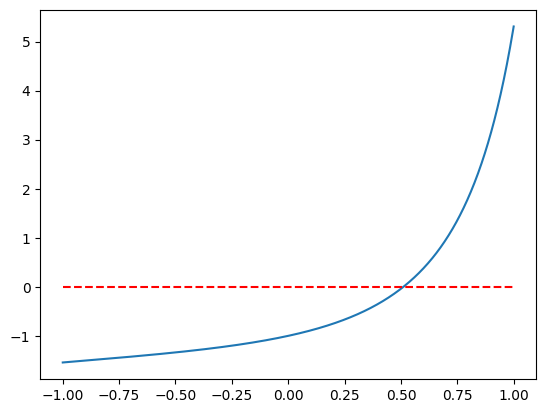

In [28]:
f=lambda x: x/(1-np.sin(x))-1
a=-1
b=1
x_grid=np.linspace(a, b, 1000)

plt.plot(x_grid, f(x_grid))
plt.plot(x_grid, np.zeros_like(x_grid), '--r')

In [29]:
#la funzione ha uno zero in x=0.5; ha molteplicità algebrica 1


##### **Soluzione.**

Una possibile implementazione e' data dal seguente codice.

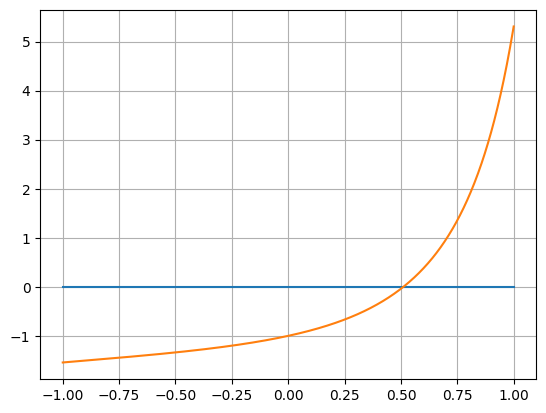

In [35]:
f = lambda x: x / (1 - np.sin(x)) - 1

xplot = np.linspace(-1, 1, 1000)

plt.plot(xplot, np.zeros_like(xplot))
plt.plot(xplot, f(xplot))
plt.grid()

Lo zero di $f$ risulta essere vicino a $0.5$, graficamente possiamo anche dire che e' uno zero semplice.

#### **(2b) (3 punti) [T]**

Riformulare il problema precedente in uno equivalente ma che richiede la ricerca di un punto fisso per la funzione $\phi$, ovvero che $\alpha$ soddisfa
$$
    \alpha = \phi(\alpha)
$$

Proporre una funzione di iterazione $\phi$ e verificare che l'algoritmo di punto fisso risulta (localmente) convergente verificando la condizione di convergenza prevista dalla teoria.

##### **Soluzione.**

Possiamo considerare la funzione di iterazione $\phi$ pari a
$$
    \phi(x) = 1 - \sin(x)
$$
Per garantire che il metodo di punto fisso sia convergente dobbiamo avere che $|\phi^\prime(x)| < 1$ per ogni $x$ in un intorno di $\alpha$.
Calcoliamo quindi $\phi^\prime$
$$
    \phi^\prime(x) = -\cos(x)
$$
che risulta essere sempre minore di $1$ nell'intervallo $(0, 1)$.

#### **(2c) (2 punti) [P]**

Completare la seguente implementazione del metodo di punto fisso.

In [30]:
def puntofisso(phi, x0, toll, maxit):
    err = toll + 1
    it = 0
    x = x0
    while err>toll and it<maxit:
        x_new = phi(x)
        err = np.abs(x_new-x)
        x = x_new
        it += 1
    return x

##### **Soluzione.**

Una possibile implementazione e' data dal codice seguente

In [ ]:
def puntofisso(phi, x0, toll, maxit):
    err = toll + 1
    it = 0
    x = x0
    while it < maxit and err > toll:
        x_new = phi(x)
        err = np.abs(x - x_new)
        x = x_new
        it += 1
    return x

#### **(2d) (2 punti) [P+T]**

Si risolva il problema utilizzando la funzione scritta per calcolare lo zero di $f$, utilizzando come valore di partenza $x_0=0.1$. Si consideri una tolleranza e un numero massimo di iterazioni appropriato. Calcolare il residuo corrispondente alla soluzione trovata e commentare il risultato.

In [37]:
x0=0.1
toll=1e-6
maxit=100
phi=lambda x: 1-np.sin(x)

x=puntofisso(phi, x0, toll, maxit)

print(x)

res=np.abs(f(x))
print(res)

0.5109729992010512
1.5762583986944634e-06


##### **Soluzione.**

Una possibile implementazione e' data dal codice seguente

In [36]:
phi = lambda x: 1 - np.sin(x)

x = puntofisso(phi, 0.1, 1e-6, 100)
print(x)
print(np.abs(f(x)))

0.5109729992010512
1.5762583986944634e-06


# **Esercizio 3 (11 punti)**

Consideriamo il seguente problema tempo-dipendente nel caso monodimensionale, sul dominio $\Omega_T=\Omega\times[0,T)$, con $\Omega=(0,1)$:

Dati $u_0:\Omega\longrightarrow\mathbb{R}$, $f:\Omega\longrightarrow\mathbb{R}$, trovare $u:\Omega_T\longrightarrow\mathbb{R}$ tale che:

$$\begin{cases}
			\partial_t u - \partial_x(\partial_x u) = f, & \text{in}\ \Omega_T, \\
			u(0,t) = 0, & \text{per}\ t\in[0,T), \\
			u(1,t) = 0, & \text{per}\ t\in[0,T), \\
			u(x,t=0) = u_0, & \text{in}\ \Omega\times\{0\}.
\end{cases}$$

dove il tempo finale è pari a $T=1$ e $u_0(x) = \sin(2\pi x)$.

#### **(3a) (2 punti) [T]**

Verificare che $u(x,t) = \sin(2\pi x)(1-2t)$ soddisfa le condizioni al bordo e la condizione iniziale. Calcolare la forzante $f$ tale per cui $u(x,t)$ è soluzione esatta dell'equazione.

##### **Soluzione.**

Condizioni al bordo: $u(0,t) = sin(0)(1-2t)=0$, $u(1,t) = sin(2\pi)(1-2t)=0$.

Condizione iniziale: $u(x,0) = \sin(2\pi x)$.


Calcoliamo $\partial_{x^2} u = -4\pi^2\sin(2\pi x)(1-2t)$ e $\partial_t u = -2\sin(2\pi x)$. Sostituiamo nell'equazione ottenendo:

$$ -2 \sin(2\pi x) + 4\pi^2 \sin(2\pi x)(1-2t) = f$$

Da cui $f(x,t) = \sin(2\pi x)(-2+4\pi^2-8\pi^2 t)$.

#### **(3b) (4 punti) [T]**

Illustrare brevemente il metodo di discretizzazione per l'equazione proposta basato su:

- gli elementi finiti per la discretizzazione in spazio
- il θ-metodo per la discretizzazione in tempo.
    
Derivare la forma matriciale del problema discreto.


##### **Soluzione.**

Consideriamo ora lo spazio funzionale $V=H^1_0(\Omega)$
e prendiamo delle funzioni test $v \in V$ che sono indipendenti da $t$; la forma
debole del problema definita dall'equazione del calore è data da: trovare, per
ogni $t \in (0, 1)$, $u(x, t) \in V$ tale che
\begin{gather*}
    \int_0^1 {\partial_t u} v dx
    +\int_0^1     \partial_x u
    \partial_x v dx = \int_0^1 f v dx \qquad
    \forall v \in V.
\end{gather*}
La formulazione discreta del problema è derivata fissando il tempo ed operando
prima in spazio. Scegliendo $V_h \subset V$ sotto-spazio finito
dimensionale otteniamo che la semi-discretizzazione in spazio è: trovare, per
ogni $t \in (0, 1)$, $u_h(t) \in V_h$ tale che
\begin{gather*}
    \int_0^1 \partial_t u_h v_h dx
    +\int_0^1  
    \partial_x u_h \partial_x v_h dx =
    \int_0^1 f v_h dx \qquad
    \forall v_h \in V_h.
\end{gather*}
Introduciamo ora le forme $a$ e $m$ e il funzionale $F$ definiti
come
\begin{gather*}
    a(u_h, v_h) = \int_0^1 \partial_x u_h
    \partial_x v_h
    \quad\text{e} \quad
    m(u_h, v_h) = \int_0^1 u_h v_h
    \quad\text{e} \quad
    F(v_h) = \int_0^1 f v_h dx
\end{gather*}
il precedente problema può quindi essere scritto come:
\begin{gather*}
    m(\partial_t u_h(t), v_h)
    + a(u_h, v_h) =
    F(v_h) \qquad
    \forall v_h \in V_h.
\end{gather*}
Anche in questo caso consideriamo una base $\{\phi_j\}$ per $V_h$ di funzioni
linearmente indipendenti,
consideriamo lo sviluppo di $v_h$ e $u_h$ sulla base $\{\phi_j \}$ di $V_h$
otteniamo
\begin{gather*}
    v_h(x) = \sum_{i=1}^{N_h} \alpha_i \phi_i (x)
    \quad \text{e} \quad
    u_h(x, t) = \sum_{j=1}^{N_h} u_j(t) \phi_j (x)
\end{gather*}

Sfruttando la bi-linearità della forma $a$, il fatto che il dominio non
dipende dal tempo e la linearità del funzionale $F$
otteniamo la seguente espressione
\begin{gather*}
    \partial_t m\left(\sum_{j=1}^{N_h} u_j(t) \phi_j, \phi_i\right)
    + a\left(\sum_{j=1}^{N_h} u_j(t) \phi_j, \phi_i\right) =
    F(\phi_i) \qquad
    \forall i=1,\ldots, N_h\\
    \sum_{j=1}^{N_h} \partial_t u_j(t)
    m\left(\phi_j, \phi_i\right)
    + \sum_{j=1}^{N_h} u_j(t) a\left(\phi_j, \phi_i\right) =
    F(\phi_i) \qquad
    \forall i=1,\ldots, N_h,
\end{gather*}
introduciamo la matrice di rigidezza $A$ e di massa $M$ date rispettivamente da
\begin{gather*}
    A \in \mathbb{R}^{N_h \times N_h}: \quad a_{ij} = a\left(\phi_j,
    \phi_i\right) \\
    M \in \mathbb{R}^{N_h \times N_h}: \quad m_{ij} = m\left( \phi_j,
    \phi_i \right)
\end{gather*}
Notiamo che la matrice di massa ha la stessa struttura della matrice introdotta per descrivere il termine di reazione in precedenza.
Il problema semi-discreto risulta quindi di determinare il vettore tempo
dipendente $\mathbf{u}(t)$ tale che
\begin{gather*}
    M d_t \mathbf{u}(t) + A \mathbf{u}(t) =
    \mathbf{f}.
\end{gather*}
Notiamo che abbiamo un sistema di equazioni differenziali ordinarie in tempo di
dimensione $N_h$, che può essere scritto formalmente nel seguente modo
\begin{gather*}
    \begin{cases}
        d_t \mathbf{u}(t) = \mathbf{\tilde{f}}(t, \mathbf{u}) \\
        \mathbf{u}(0) = \mathbf{u}_0
    \end{cases}
\end{gather*}
dove appunto $\mathbf{\tilde{f}}(t, \mathbf{u}) = - M^{-1} A \mathbf{u}(t) + M^{-1}\mathbf{f}$. La soluzione iniziale $\mathbf{u}_0$ dipende solamente
dallo spazio e può essere approssimata come
\begin{gather*}
    u_{0,h}(x) = \sum_{j=1}^{N_h} u_{0,j} \phi_j (x).
\end{gather*}
Introduciamo quindi ora una discretizzazione in tempo, ovvero
dividiamo l'intervallo $(0, 1]$ in $N_t$ sotto-intervalli temporali tale che
\begin{gather*}
    t_0 = 0 \qquad t_{N_t} = 1 \qquad t^n = n \Delta t,
\end{gather*}
dove $\Delta t$ è il passo di discretizzazione temporale definito come $\Delta t = 1/N_t$. Possiamo quindi utilizzare gli schemi di avanzamento temporale già
studiati, in particolare la derivata in tempo viene discretizzata come
\begin{gather*}
    d_t \mathbf{u} \approx \frac{\mathbf{u}(t^{n+1}) - \mathbf{u}(t^{n}) }{\Delta t} =
    \frac{\mathbf{u}^{n+1} - \mathbf{u}^{n} }{\Delta t}.
\end{gather*}
Il $\theta$-metodo può essere ora scritto come
\begin{gather*}
    M \frac{\mathbf{u}^{n+1} - \mathbf{u}^{n} }{\Delta t} + \theta A \mathbf{u}^{n+1} +
    (1-\theta) A \mathbf{u}^n = \theta \mathbf{f}^{n+1} + (1-\theta) \mathbf{f}^n
\end{gather*}
che è un sistema algebrico che dobbiamo risolvere ad ogni passo di
discretizzazione temporale. Ad ogni istante temporale dobbiamo risolvere un
problema del tipo
\begin{gather*}
    \left( \frac{M}{\Delta t} +  \theta A \right) \mathbf{u}^{n+1} = \left( \frac{M}{\Delta t}
    - (1-\theta) A \right)
    \mathbf{u}^n + \theta \mathbf{f}^{n+1} + (1-\theta) \mathbf{f}^n.
\end{gather*}

#### **(3c) (3 punti) [P]**

Completare la function heatsolve fornita nei punti indicati da ''#TODO''

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import fem
from fem import *

In [ ]:
def heatSolve(D, f, u0, L, h, T, dt, theta):
    (
        """"
  Input:
     D      (float)                  Coefficiente di diffusione (positivo).
     f      (lambda function)        Forzante. Si assume f = f(x,t).
     u0     (lambda function)        Condizione iniziale.
     L      (float)                  Lunghezza dell'intervallo spaziale.
     h      (float)                  Passo della griglia spaziale.
     T      (float)                  Tempo finale
     dt     (float)                  Passo temporale.
     theta  (float)                  Parametro del theta-metodo.

  Output:
    V                               spazio elementi finiti
    u     (numpy.ndarray)-> matrix  Matrice contenente la soluzione
                                    approssimata del problema. Uij
                                    approssima u(dof_i, tj): ogni colonna è un
                                    tempo fissato.
    t      (numpy.ndarray)-> vector Griglia temporale.
  """
        ""
    )
    # Costruisco il dominio
    domain = Line(0, L)
    # Costruisco la mesh
    mesh = generate_mesh(domain, stepsize=h)
    # Costruisco lo spazio FEM di grado 1
    Vh = FEspace(mesh, 1)

    # Costruisco la griglia temporale
    nt = np.ceil(T / dt) + 1
    t = np.zeros(int(nt))

    # Inizializzo la soluzione
    u = np.zeros((dofs(Vh).size, int(nt)))

    # Definisco la condizione iniziale
    u0h = fun2dof(
        interpolate(u0, Vh)
    )  # Qui utilizziamo fun2dof(interpolate(.)) perchè vogliamo che u sia di tipo np.array (si veda la documentazione delle due funzioni all'interno di fem.py per maggiori dettagli)
    u[:, 0] = u0h

    # Definisco le funzioni di base
    uh = trial_function(Vh)
    vh = test_function(Vh)

    # Matrice di massa
    def m(u, v):
        return #TODO

    # Assemblaggio matrice di massa
    M = assemble(m(uh, vh))

    # Matrice di diffusione
    def a(u, v):
        return deriv(u) * deriv(v) * dx

    # Assemblaggio matrice di diffusione
    A = D * assemble(a(uh, vh))

    # Ciclo temporale
    for n in range(int(nt) - 1):
        # Costruzioni termini noti al tempo dt e dt+1
        t_old = n * dt
        t_new = (n + 1) * dt

        fold = lambda x: f(x, t_old)
        fnew = lambda x: f(x, t_new)

        fold_h = interpolate(fold, Vh)
        fnew_h = interpolate(fnew, Vh)

        # Costruzione funzionali lineari
        def l(f, v):
            return f * v * dx

        Fold = assemble(l(fold_h, vh))
        Fnew = assemble(l(fnew_h, vh))

        # Applico condizioni di Dirichlet alle matrici del sistema
        def isLeftNode(x):
            return x < 1e-12

        def isRightNode(x):
            return x > L - 1e-12

        dbc1 = DirichletBC(isLeftNode, 0.0)
        dbc2 = DirichletBC(isRightNode, 0.0)

        A = applyBCs(A, Vh, dbc1, dbc2)
        M = applyBCs(M, Vh, dbc1, dbc2)
        Fold = applyBCs(Fold, Vh, dbc1, dbc2)
        Fnew = applyBCs(Fnew, Vh, dbc1, dbc2)

        # Costruzione del sistema lineare e sua risoluzione
        B = #TODO
        b = #TODO

        from scipy.sparse.linalg import spsolve

        u[:, n + 1] = spsolve(B, b)
        t[n + 1] = t_new

    return Vh, u, t


In [52]:
from fem_utils_lez import*
def heat_solve(grid, D, f, u0, T, dt, theta):
  """"
  Input:
     grid    Grid object providing nodal coordinates in grid.nodes.
     D      (float)                  Coefficiente di diffusione (positivo).
     f      (lambda function)        Forzante. Si assume f = f(x,t).
     u0     (lambda function)        Condizione iniziale.
     T      (float)                  Tempo finale
     dt     (float)                  Passo temporale.
     theta  (float)                  Parametro del theta-metodo.

  Output:
    uh     (numpy.ndarray)-> matrix  Matrice contenente la soluzione approssimata del problema. 
                                      Uij approssima uh(dof_i, t_j): ogni colonna è un tempo fissato.
    th      (numpy.ndarray)-> vector Griglia temporale.
  """""
  # estrazione informazione dalla griglia/mesh
  h=grid.h
  Nele=grid.N
  nodes=grid.nodes
  
  # Griglia temporale  
  Nt=int(T/dt)
  th=np.linspace(0, T, Nt)

  # Inizializzo la soluzione
  uh=np.zeros((len(nodes),len(th)))
    
  # condizione iniziale
  uh0=u0(nodes)
  uh[:,0]=uh0

  # Boundary conditions (Dirichlet)
  dirichlet_nodes=[0, Nele]
  dirichlet_values=[0,0]

  # Costruzione del vettore dei valori al bordo
  bc_values=np.zeros(Nele+1)
  bc_values[dirichlet_nodes]=dirichlet_values

  # Matrice di restrizione R
  keep_dof=np.ones(Nele+1, dtype=bool)
  keep_dof[dirichlet_nodes]=False
  R=create_restriction(keep_dof)

  # Costruzione matrici di massa e diffusione
  M=mass(grid)
  A=D*diffusion(grid)

  # Costruzioni matrici per il theta metodo
  G=M/dt+A
  G_0= R @ G @R.T

  # Ciclo temporale
  for i in range(len(th)-1):
    t_old=th[i]
    t_new=th[i+1]
    
    f_old=f(nodes,t_old)
    f_new=f(nodes,t_new)
    
    F_old=M@f_old
    F_new=M@f_new

    g=(M/dt-(1-theta)*A)@ uh[:,i]+theta*F_new+(1-theta)*F_old
    g_0= R @ (g- G@bc_values)

    u_new_0=np.linalg.solve(G_0, g_0)

    uh[:, i+1]= R.T @ u_new_0 +bc_values
  return uh, th

##### **Soluzione.**

Una possibile soluzione è implementata di seguito.

In [ ]:
def heatSolve(D, f, u0, L, h, T, dt, theta):
    (
        """"
  Input:
     D      (float)                  Coefficiente di diffusione (positivo).
     f      (lambda function)        Forzante. Si assume f = f(x,t).
     u0     (lambda function)        Condizione iniziale.
     L      (float)                  Lunghezza dell'intervallo spaziale.
     h      (float)                  Passo della griglia spaziale.
     T      (float)                  Tempo finale
     dt     (float)                  Passo temporale.
     theta  (float)                  Parametro del theta-metodo.

  Output:
    V                               spazio elementi finiti
    u     (numpy.ndarray)-> matrix  Matrice contenente la soluzione
                                    approssimata del problema. Uij
                                    approssima u(dof_i, tj): ogni colonna è un
                                    tempo fissato.
    t      (numpy.ndarray)-> vector Griglia temporale.
  """
        ""
    )
    # Costruisco il dominio
    domain = Line(0, L)
    # Costruisco la mesh
    mesh = generate_mesh(domain, stepsize=h)
    # Costruisco lo spazio FEM di grado 1
    Vh = FEspace(mesh, 1)

    # Costruisco la griglia temporale
    nt = np.ceil(T / dt) + 1
    t = np.zeros(int(nt))

    # Inizializzo la soluzione
    u = np.zeros((dofs(Vh).size, int(nt)))

    # Definisco la condizione iniziale
    u0h = fun2dof(
        interpolate(u0, Vh)
    )  # Qui utilizziamo fun2dof(interpolate(.)) perchè vogliamo che u sia di tipo np.array (si veda la documentazione delle due funzioni all'interno di fem.py per maggiori dettagli)
    u[:, 0] = u0h

    # Definisco le funzioni di base
    uh = trial_function(Vh)
    vh = test_function(Vh)

    # Matrice di massa
    def m(u, v):
        return u * v * dx

    # Assemblaggio matrice di massa
    M = assemble(m(uh, vh))

    # Matrice di diffusione
    def a(u, v):
        return deriv(u) * deriv(v) * dx

    # Assemblaggio matrice di diffusione
    A = D * assemble(a(uh, vh))

    # Ciclo temporale
    for n in range(int(nt) - 1):
        # Costruzioni termini noti al tempo dt e dt+1
        t_old = n * dt
        t_new = (n + 1) * dt

        fold = lambda x: f(x, t_old)
        fnew = lambda x: f(x, t_new)

        fold_h = interpolate(fold, Vh)
        fnew_h = interpolate(fnew, Vh)

        # Costruzione funzionali lineari
        def l(f, v):
            return f * v * dx

        Fold = assemble(l(fold_h, vh))
        Fnew = assemble(l(fnew_h, vh))

        # Applico condizioni di Dirichlet alle matrici del sistema
        def isLeftNode(x):
            return x < 1e-12

        def isRightNode(x):
            return x > L - 1e-12

        dbc1 = DirichletBC(isLeftNode, 0.0)
        dbc2 = DirichletBC(isRightNode, 0.0)

        A = applyBCs(A, Vh, dbc1, dbc2)
        M = applyBCs(M, Vh, dbc1, dbc2)
        Fold = applyBCs(Fold, Vh, dbc1, dbc2)
        Fnew = applyBCs(Fnew, Vh, dbc1, dbc2)

        # Costruzione del sistema lineare e sua risoluzione
        B = M / dt + theta * A
        b = (M / dt - (1 - theta) * A) @ u[:, n] + theta * Fnew + (1 - theta) * Fold

        from scipy.sparse.linalg import spsolve

        u[:, n + 1] = spsolve(B, b)
        t[n + 1] = t_new

    return Vh, u, t


#### **(3d) (3 punti) [P]**

Dopo avere definito i dati necessari, risolvere il problema con la function *heatsolve* usando il metodo di Crank-Nicolson in tempo, una dimensione della griglia $h=0.1$ e un passo temporale $\Delta t = 0.1$.

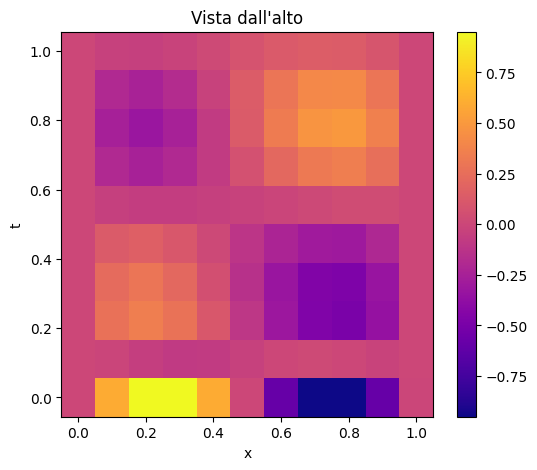

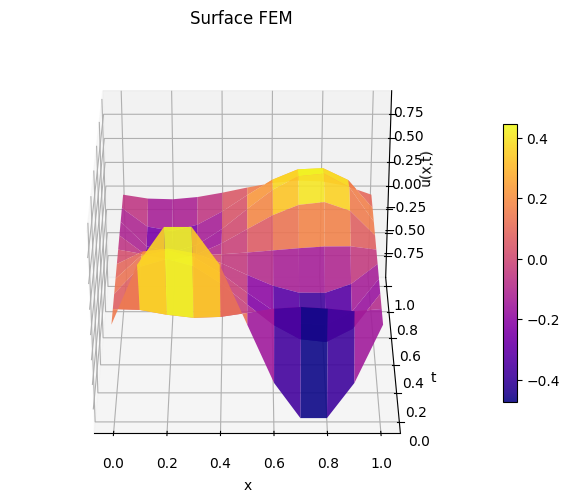

In [55]:
from fem_utils_plot import*
a=0
b=1
h=0.1
N=int(b/h)
grid=Grid(a,b, N)
grid.compute_geometry()
D=1
f=lambda t, x: (4*np.pi**2 - 8*np.pi**2*t -2)*np.sin(2*np.pi*x)
u0= lambda x: np.sin(2*np.pi*x)
T=1
dt=0.1
theta=0.5
uh,th=heat_solve(grid, D, f, u0, T, dt, theta)
xtplot(grid, uh, th, 'surface')


##### **Soluzione.**

Scegliamo $\theta = 0.5$ per ottenere il metodo di Crank-Nicolson.

In [ ]:
# Dati del problema del calore
T = 1
dt = 0.1

# Dominio
L = 1
h = 0.1
# Coefficiente di diffusione
D = 1
# Parametro per il theta methodo
theta = 0.5
# Termine noto
f = lambda x, t: np.sin(2 * np.pi * x) * (-2 + 4 * np.pi**2 - 8 * np.pi**2 * t)
# Condizione iniziale
u0 = lambda x: np.sin(2 * np.pi * x)

# Risoluzione equazione del calore
Vh, uh, t = heatSolve(D, f, u0, L, h, T, dt, theta)
xtplot(Vh, uh, t)

#### **(3e) (2 punti) [P+T]**

Calcolare la soluzione esatta al tempo finale e confrontarla graficamente con la soluzione numerica allo stesso tempo. Commentare il risultato ottenuto.

##### **Soluzione.**

La soluzione esatta fornita va valutata in $t=T=1$. Per quanto riguarda la soluzione numerica è sufficiente estrarre l'ultima colonna (ultimo tempo) dalla matrice uh dei gradi di libertà. I risultati sono in buon accordo nonostante la griglia coarse e il passo temporale lungo.

In [ ]:
xplot = np.linspace(0, L, 100)
uex = lambda x, t: np.sin(2 * np.pi * x) * (1 - 2 * t)

fem.plot(dof2fun(uh[:, -1], Vh))
plt.plot(xplot, uex(xplot, 1))